In [2]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

In [4]:
df = pd.read_csv("../data/raw/student_performance.csv")

In [5]:
df.head()

,student_id,attendance,internal_marks,study_hours,previous_performance,assignment_score,result
0,S00001,88.2,67.7,3.6,66.5,57.2,Fail
1,S00002,83.4,62.3,2.1,54.0,58.0,Pass
2,S00003,88.4,55.0,3.7,66.7,56.7,Pass
3,S00004,86.4,69.0,3.4,78.2,65.0,Pass
4,S00005,74.7,52.9,4.5,50.5,49.4,Pass


In [6]:
df.tail()


,student_id,attendance,internal_marks,study_hours,previous_performance,assignment_score,result
4995,S04996,98.5,77.6,4.2,89.8,92.3,Pass
4996,S04997,69.8,59.7,3.4,62.4,73.1,Fail
4997,S04998,87.6,57.9,7.7,73.8,65.5,Pass
4998,S04999,83.8,53.3,3.9,76.2,50.1,Pass
4999,S05000,85.8,47.8,2.2,56.4,41.1,Fail


In [7]:
df.shape

(5000, 7)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   str    
 1   attendance            5000 non-null   float64
 2   internal_marks        5000 non-null   float64
 3   study_hours           5000 non-null   float64
 4   previous_performance  5000 non-null   float64
 5   assignment_score      5000 non-null   float64
 6   result                5000 non-null   str    
dtypes: float64(5), str(2)
memory usage: 322.4 KB


In [9]:
df.describe()

,attendance,internal_marks,study_hours,previous_performance,assignment_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,78.555480,62.697880,3.633820,65.813120,65.89278
std,10.102155,13.806829,1.599711,12.305124,12.96030
min,40.400000,13.600000,0.700000,30.000000,8.50000
25%,71.500000,53.100000,2.500000,57.475000,56.80000
50%,79.300000,62.300000,3.300000,65.800000,65.80000
75%,85.800000,71.900000,4.500000,74.000000,74.50000
max,100.000000,100.000000,10.000000,100.000000,100.00000


In [10]:
df.describe()

,attendance,internal_marks,study_hours,previous_performance,assignment_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,78.555480,62.697880,3.633820,65.813120,65.89278
std,10.102155,13.806829,1.599711,12.305124,12.96030
min,40.400000,13.600000,0.700000,30.000000,8.50000
25%,71.500000,53.100000,2.500000,57.475000,56.80000
50%,79.300000,62.300000,3.300000,65.800000,65.80000
75%,85.800000,71.900000,4.500000,74.000000,74.50000
max,100.000000,100.000000,10.000000,100.000000,100.00000


In [11]:
df.columns

Index(['student_id', 'attendance', 'internal_marks', 'study_hours',
       'previous_performance', 'assignment_score', 'result'],
      dtype='str')

In [12]:
df.dtypes

student_id                  str
attendance              float64
internal_marks          float64
study_hours             float64
previous_performance    float64
assignment_score        float64
result                      str
dtype: object

In [13]:
df["result"].value_counts()

result
Pass    3492
Fail    1508
Name: count, dtype: int64

In [14]:
df.isnull().sum()

student_id              0
attendance              0
internal_marks          0
study_hours             0
previous_performance    0
assignment_score        0
result                  0
dtype: int64

In [15]:
df.duplicated().sum()


np.int64(0)

In [16]:
df = df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df["student_id"].nunique()

5000

In [19]:
len(df)

5000

In [20]:
df[[
    "attendance",
    "internal_marks",
    "study_hours",
    "previous_performance",
    "assignment_score"
]].describe()

,attendance,internal_marks,study_hours,previous_performance,assignment_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,78.555480,62.697880,3.633820,65.813120,65.89278
std,10.102155,13.806829,1.599711,12.305124,12.96030
min,40.400000,13.600000,0.700000,30.000000,8.50000
25%,71.500000,53.100000,2.500000,57.475000,56.80000
50%,79.300000,62.300000,3.300000,65.800000,65.80000
75%,85.800000,71.900000,4.500000,74.000000,74.50000
max,100.000000,100.000000,10.000000,100.000000,100.00000


In [21]:
print("Attendance outside 0-100:")
print(df[(df["attendance"] < 0) | (df["attendance"] > 100)])

print("Internal marks outside 0-100:")
print(df[(df["internal_marks"] < 0) | (df["internal_marks"] > 100)])

print("Previous performance outside 0-100:")
print(df[(df["previous_performance"] < 0) | (df["previous_performance"] > 100)])

print("Assignment score outside 0-100:")
print(df[(df["assignment_score"] < 0) | (df["assignment_score"] > 100)])

print("Negative study hours:")
print(df[df["study_hours"] < 0])

Attendance outside 0-100:
Empty DataFrame
Columns: [student_id, attendance, internal_marks, study_hours, previous_performance, assignment_score, result]
Index: []
Internal marks outside 0-100:
Empty DataFrame
Columns: [student_id, attendance, internal_marks, study_hours, previous_performance, assignment_score, result]
Index: []
Previous performance outside 0-100:
Empty DataFrame
Columns: [student_id, attendance, internal_marks, study_hours, previous_performance, assignment_score, result]
Index: []
Assignment score outside 0-100:
Empty DataFrame
Columns: [student_id, attendance, internal_marks, study_hours, previous_performance, assignment_score, result]
Index: []
Negative study hours:
Empty DataFrame
Columns: [student_id, attendance, internal_marks, study_hours, previous_performance, assignment_score, result]
Index: []


In [22]:
df["result"].unique()

<ArrowStringArray>
['Fail', 'Pass']
Length: 2, dtype: str

In [23]:
df["result"].value_counts()

result
Pass    3492
Fail    1508
Name: count, dtype: int64

In [24]:
df["result"].value_counts(normalize=True) * 100

result
Pass    69.84
Fail    30.16
Name: proportion, dtype: float64

In [25]:
features = [
    "attendance",
    "internal_marks",
    "study_hours",
    "previous_performance",
    "assignment_score"
]

X = df[features]
y = df["result"]

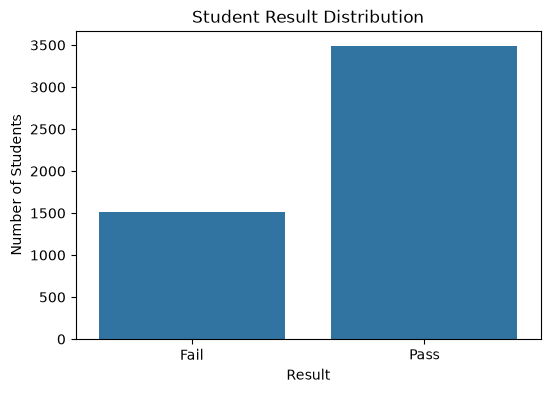

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="result")

plt.title("Student Result Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.show()

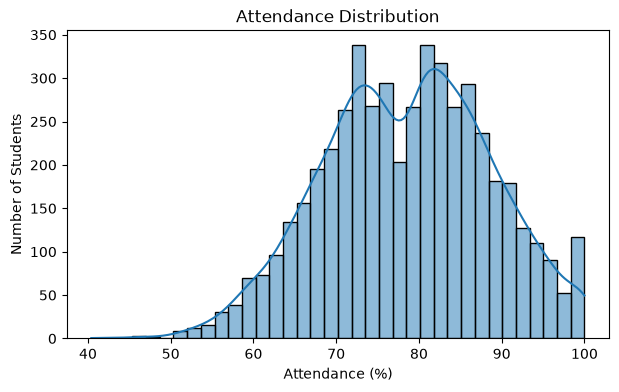

In [27]:
plt.figure(figsize=(7,4))

sns.histplot(data=df, x="attendance", kde=True)

plt.title("Attendance Distribution")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Students")

plt.show()

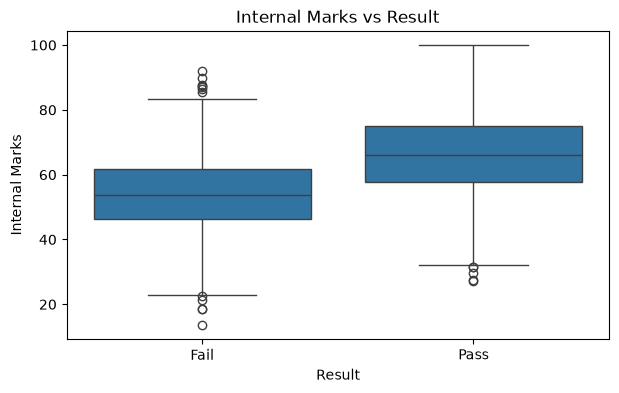

In [28]:
plt.figure(figsize=(7,4))

sns.boxplot(data=df, x="result", y="internal_marks")

plt.title("Internal Marks vs Result")
plt.xlabel("Result")
plt.ylabel("Internal Marks")

plt.show()

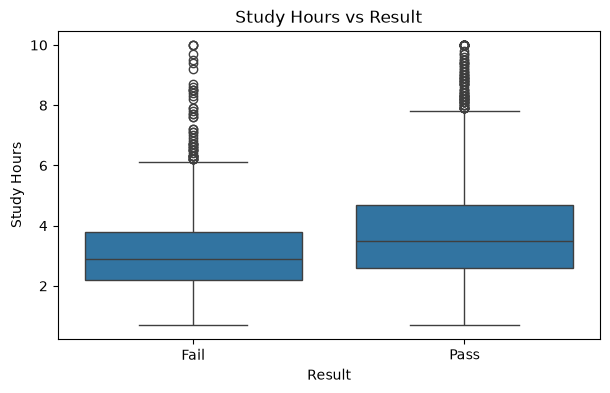

In [30]:
plt.figure(figsize=(7,4))

sns.boxplot(data=df, x="result", y="study_hours")

plt.title("Study Hours vs Result")
plt.xlabel("Result")
plt.ylabel("Study Hours")

plt.show()

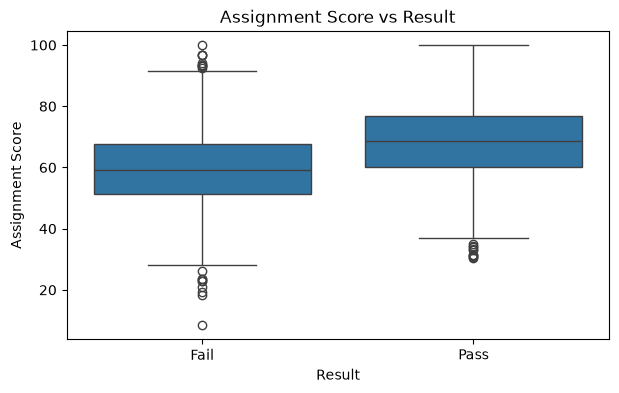

In [31]:
plt.figure(figsize=(7,4))

sns.boxplot(data=df, x="result", y="assignment_score")

plt.title("Assignment Score vs Result")
plt.xlabel("Result")
plt.ylabel("Assignment Score")

plt.show()

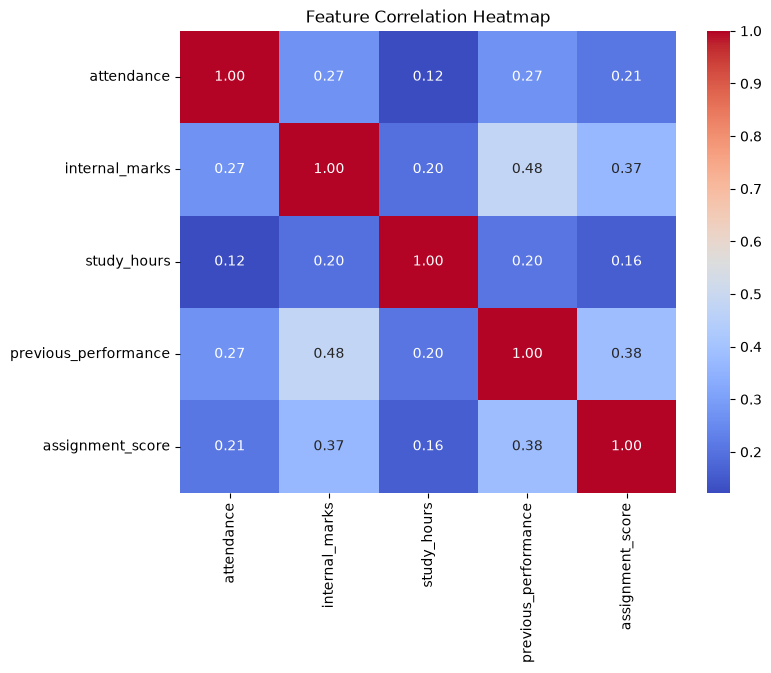

In [32]:
numeric_columns = [
    "attendance",
    "internal_marks",
    "study_hours",
    "previous_performance",
    "assignment_score"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [33]:
X = df[
    [
        "attendance",
        "internal_marks",
        "study_hours",
        "previous_performance",
        "assignment_score"
    ]
]

y = df["result"]

In [34]:
X.head()

,attendance,internal_marks,study_hours,previous_performance,assignment_score
0,88.2,67.7,3.6,66.5,57.2
1,83.4,62.3,2.1,54.0,58.0
2,88.4,55.0,3.7,66.7,56.7
3,86.4,69.0,3.4,78.2,65.0
4,74.7,52.9,4.5,50.5,49.4


In [35]:
y.head()

0    Fail
1    Pass
2    Pass
3    Pass
4    Pass
Name: result, dtype: str

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [37]:
numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [38]:
numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [39]:
numeric_preprocessor = Pipeline([...])

In [40]:
numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [41]:
print(numeric_preprocessor)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [42]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4000, 5)
X_test: (1000, 5)
y_train: (4000,)
y_test: (1000,)


In [43]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
result
Pass    2794
Fail    1206
Name: count, dtype: int64

Testing class distribution:
result
Pass    698
Fail    302
Name: count, dtype: int64


In [44]:
logistic_model = Pipeline([
    ("preprocessor", numeric_preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])

In [45]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Fail','Pass']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['attendance','internal_marks','study_hours','previous_performance', 'assignment_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepi

In [46]:
y_pred_lr = logistic_model.predict(X_test)

In [47]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.796


In [48]:
print(
    "Logistic Regression Accuracy:",
    round(lr_accuracy * 100, 2),
    "%"
)

Logistic Regression Accuracy: 79.6 %


In [49]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

        Fail       0.70      0.56      0.62       302
        Pass       0.82      0.90      0.86       698

    accuracy                           0.80      1000
   macro avg       0.76      0.73      0.74      1000
weighted avg       0.79      0.80      0.79      1000



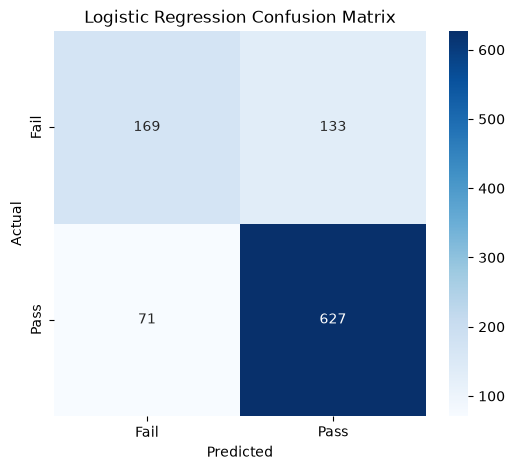

In [50]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [51]:
decision_tree_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

In [52]:
decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Fail','Pass']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['attendance','internal_marks','study_hours','previous_performance', 'assignment_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_va

In [53]:
y_pred_dt = decision_tree_model.predict(X_test)

In [54]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(
    "Decision Tree Accuracy:",
    round(dt_accuracy * 100, 2),
    "%"
)

Decision Tree Accuracy: 75.9 %


In [55]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

        Fail       0.64      0.45      0.53       302
        Pass       0.79      0.89      0.84       698

    accuracy                           0.76      1000
   macro avg       0.72      0.67      0.68      1000
weighted avg       0.75      0.76      0.75      1000



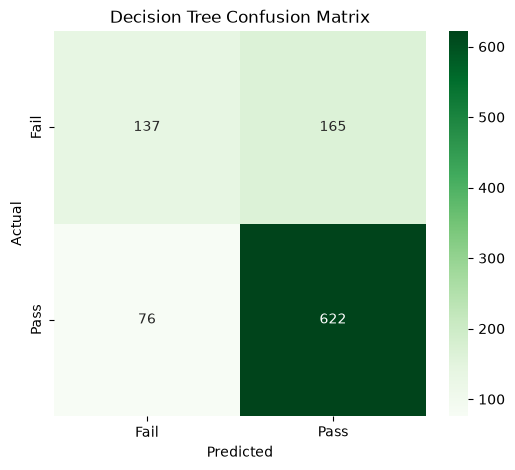

In [56]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [57]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.796
1,Decision Tree,0.759


In [58]:
if dt_accuracy > lr_accuracy:
    best_model = decision_tree_model
    best_model_name = "Decision Tree"
else:
    best_model = logistic_model
    best_model_name = "Logistic Regression"

print("Selected Model:", best_model_name)

Selected Model: Logistic Regression


In [59]:
joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

['../models/best_model.pkl']

In [60]:
loaded_model = joblib.load("../models/best_model.pkl")

In [61]:
test_prediction = loaded_model.predict(X_test.iloc[:5])

print(test_prediction)

['Pass' 'Fail' 'Fail' 'Pass' 'Pass']


In [62]:
new_student = pd.DataFrame({
    "attendance": [85],
    "internal_marks": [72],
    "study_hours": [4],
    "previous_performance": [75],
    "assignment_score": [80]
})

In [63]:
prediction = loaded_model.predict(new_student)

print("Predicted Result:", prediction[0])

Predicted Result: Pass


In [64]:
probability = loaded_model.predict_proba(new_student)

print(probability)

[[0.04813788 0.95186212]]


In [65]:
classes = loaded_model.classes_

for class_name, probability_value in zip(
    classes,
    probability[0]
):
    print(
        class_name,
        ":",
        round(probability_value * 100, 2),
        "%"
    )

Fail : 4.81 %
Pass : 95.19 %


In [66]:
def predict_student(
    attendance,
    internal_marks,
    study_hours,
    previous_performance,
    assignment_score
):

    student = pd.DataFrame({
        "attendance": [attendance],
        "internal_marks": [internal_marks],
        "study_hours": [study_hours],
        "previous_performance": [previous_performance],
        "assignment_score": [assignment_score]
    })

    prediction = loaded_model.predict(student)[0]

    probabilities = loaded_model.predict_proba(student)[0]

    classes = loaded_model.classes_

    probability_dict = dict(
        zip(classes, probabilities)
    )

    return prediction, probability_dict

In [67]:
result, probabilities = predict_student(
    85,
    72,
    4,
    75,
    80
)

print("Prediction:", result)
print("Probabilities:", probabilities)

Prediction: Pass
Probabilities: {'Fail': np.float64(0.048137881989790965), 'Pass': np.float64(0.951862118010209)}


In [68]:
%whos

Variable                 Type         Data/Info
-----------------------------------------------
DecisionTreeClassifier   ABCMeta      <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
LogisticRegression       type         <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
Pipeline                 ABCMeta      <class 'sklearn.pipeline.Pipeline'>
SimpleImputer            type         <class 'sklearn.impute._base.SimpleImputer'>
StandardScaler           type         <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                        DataFrame    Shape: (5000, 5)
X_test                   DataFrame    Shape: (1000, 5)
X_train                  DataFrame    Shape: (4000, 5)
accuracy_score           function     <function accuracy_score at 0x0000014E73D05080>
best_model               Pipeline     Pipeline(steps=[('preproc<...>ssion(random_state=42))])
best_model_name          str          Logistic Regression
class_name               str          Pass
classes            

In [69]:
logistic_model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Fail','Pass']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['attendance','internal_marks','study_hours','previous_performance', 'assignment_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepi

In [70]:
logistic_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Fail','Pass']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['attendance','internal_marks','study_hours','previous_performance', 'assignment_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepi

In [71]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [72]:
numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [73]:
preprocessor = numeric_preprocessor

In [74]:
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

In [75]:
lr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Fail','Pass']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['attendance','internal_marks','study_hours','previous_performance', 'assignment_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipelin

In [76]:
lr_predictions = lr_model.predict(X_test)

In [77]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.796


In [78]:
print(lr_model)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', LogisticRegression(max_iter=2000))])


In [79]:
import joblib

best_model = lr_model

joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


In [80]:
model = joblib.load("../models/best_model.pkl")

print("Model loaded successfully!")
print(model.classes_)

Model loaded successfully!
['Fail' 'Pass']


In [81]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4000, 5)
(1000, 5)
(4000,)
(1000,)


In [82]:
lr_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Fail','Pass']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['attendance','internal_marks','study_hours','previous_performance', 'assignment_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipelin

In [83]:
logistic_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Fail','Pass']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['attendance','internal_marks','study_hours','previous_performance', 'assignment_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepi

In [84]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

In [85]:
best_model = lr_model

In [86]:
import joblib

joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


In [87]:
import joblib

model = joblib.load("../models/best_model.pkl")

print("Model loaded successfully!")
print(model)

Model loaded successfully!
Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', LogisticRegression(max_iter=2000))])


In [88]:
lr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Fail','Pass']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['attendance','internal_marks','study_hours','previous_performance', 'assignment_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipelin

In [89]:
print(lr_model)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', LogisticRegression(max_iter=2000))])


In [90]:
lr_predictions = lr_model.predict(X_test)

In [91]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.796


In [92]:
print(lr_model.classes_)

['Fail' 'Pass']


In [93]:
import joblib

best_model = lr_model

joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


In [94]:
model = joblib.load("../models/best_model.pkl")

print("Model loaded successfully!")
print("Classes:", model.classes_)

Model loaded successfully!
Classes: ['Fail' 'Pass']


In [95]:
student = pd.DataFrame({
    "attendance": [75.0],
    "internal_marks": [60.0],
    "study_hours": [3.0],
    "previous_performance": [65.0],
    "assignment_score": [70.0]
})

In [96]:
prediction = model.predict(student)[0]

print("Prediction:", prediction)

Prediction: Pass


In [97]:
probabilities = model.predict_proba(student)[0]

print("Classes:", model.classes_)
print("Probabilities:", probabilities)

Classes: ['Fail' 'Pass']
Probabilities: [0.28475266 0.71524734]


In [98]:
model = joblib.load("../models/best_model.pkl")

In [99]:
lr_model.fit(X_train, y_train)

best_model = lr_model

joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

['../models/best_model.pkl']

In [100]:
model = joblib.load("../models/best_model.pkl")

print(model.classes_)

['Fail' 'Pass']


In [101]:
print(model.classes_)

['Fail' 'Pass']


In [102]:
student = pd.DataFrame({
    "attendance": [75.0],
    "internal_marks": [60.0],
    "study_hours": [3.0],
    "previous_performance": [65.0],
    "assignment_score": [70.0]
})

In [103]:
prediction = model.predict(student)

print("Prediction:", prediction)

Prediction: ['Pass']


In [104]:
probabilities = model.predict_proba(student)[0]

print("Classes:", model.classes_)
print("Probabilities:", probabilities)

Classes: ['Fail' 'Pass']
Probabilities: [0.28475266 0.71524734]


In [105]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
student_id              0
attendance              0
internal_marks          0
study_hours             0
previous_performance    0
assignment_score        0
result                  0
dtype: int64


In [106]:
SimpleImputer(strategy="median")

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [107]:
print(model)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', LogisticRegression(max_iter=2000))])


In [108]:
Pipeline(steps=[
    ('preprocessor',
     Pipeline(steps=[
         ('imputer', SimpleImputer(strategy='median')),
         ('scaler', StandardScaler())
     ])),
    ('model', LogisticRegression(max_iter=2000))
])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each colum

In [109]:
SimpleImputer(strategy='median')

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [110]:
test_student = pd.DataFrame({
    "attendance": [75.0],
    "internal_marks": [60.0],
    "study_hours": [3.0],
    "previous_performance": [65.0],
    "assignment_score": [70.0]
})

print(test_student)

   attendance  internal_marks  study_hours  previous_performance  \
0        75.0            60.0          3.0                  65.0   

   assignment_score  
0              70.0  


In [111]:
normal_prediction = model.predict(test_student)[0]

print("Normal prediction:", normal_prediction)

Normal prediction: Pass


In [113]:
import numpy as np

In [114]:
missing_student = pd.DataFrame({
    "attendance": [75.0],
    "internal_marks": [np.nan],
    "study_hours": [3.0],
    "previous_performance": [65.0],
    "assignment_score": [70.0]
})

In [115]:
print(missing_student)

   attendance  internal_marks  study_hours  previous_performance  \
0        75.0             NaN          3.0                  65.0   

   assignment_score  
0              70.0  


In [116]:
print(missing_student.isnull().sum())

attendance              0
internal_marks          1
study_hours             0
previous_performance    0
assignment_score        0
dtype: int64


In [117]:
prediction = model.predict(missing_student)[0]

print("Prediction with missing internal marks:", prediction)

Prediction with missing internal marks: Pass


In [118]:
probabilities = model.predict_proba(missing_student)[0]

print("Classes:", model.classes_)
print("Probabilities:", probabilities)

Classes: ['Fail' 'Pass']
Probabilities: [0.25931326 0.74068674]


In [120]:
np.nan

nan

In [125]:
SimpleImputer(strategy="median")

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [126]:
train_prediction = decision_tree_model.predict(X_train)
test_prediction = decision_tree_model.predict(X_test)

train_accuracy = accuracy_score(
    y_train,
    train_prediction
)

test_accuracy = accuracy_score(
    y_test,
    test_prediction
)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.793
Testing Accuracy: 0.759


In [127]:
tree_classifier = decision_tree_model.named_steps["classifier"]

In [128]:
importance = tree_classifier.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,internal_marks,0.455793
3,previous_performance,0.293664
0,attendance,0.116042
4,assignment_score,0.095825
2,study_hours,0.038676


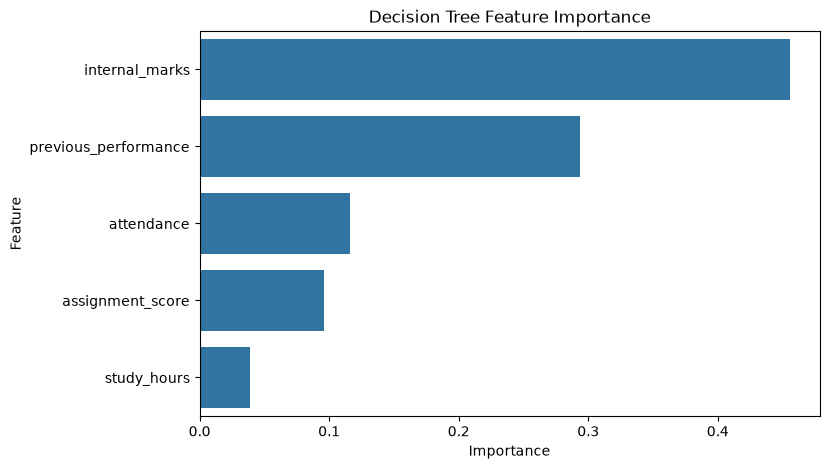

In [129]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Decision Tree Feature Importance")
plt.show()

In [130]:
results.to_csv(
    "../reports/model_results.csv",
    index=False
)

In [131]:
pd.crosstab(
    pd.cut(df["attendance"], bins=[0,50,60,70,80,90,100]),
    df["result"],
    normalize="index"
)

result,Fail,Pass
attendance,,
"(0, 50]",0.750000,0.250000
"(50, 60]",0.551515,0.448485
"(60, 70]",0.484501,0.515499
"(70, 80]",0.326769,0.673231
"(80, 90]",0.230351,0.769649
"(90, 100]",0.113737,0.886263


In [132]:
pd.crosstab(
    pd.cut(df["internal_marks"], bins=[0,40,50,60,70,80,90,100]),
    df["result"],
    normalize="index"
)

result,Fail,Pass
internal_marks,,
"(0, 40]",0.739496,0.260504
"(40, 50]",0.578947,0.421053
"(50, 60]",0.400472,0.599528
"(60, 70]",0.229391,0.770609
"(70, 80]",0.118102,0.881898
"(80, 90]",0.051597,0.948403
"(90, 100]",0.007299,0.992701


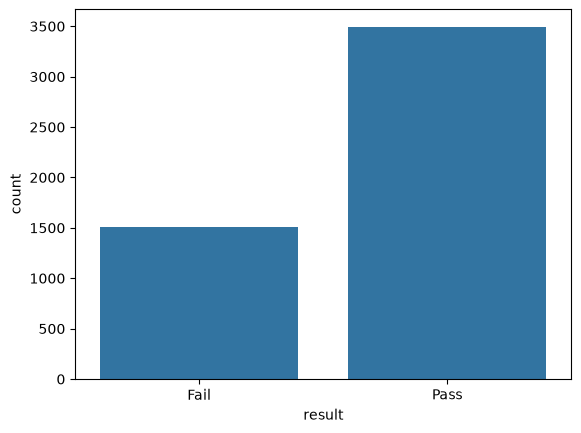

In [133]:
sns.countplot(data=df, x="result")
plt.show()

In [134]:
def data_quality_report(df):

    report = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str),
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique()
    })

    return report

In [135]:
data_quality_report(df)

,Column,Data Type,Missing Values,Unique Values
student_id,student_id,str,0,5000
attendance,attendance,float64,0,476
internal_marks,internal_marks,float64,0,675
study_hours,study_hours,float64,0,93
previous_performance,previous_performance,float64,0,620
assignment_score,assignment_score,float64,0,637
result,result,str,0,2


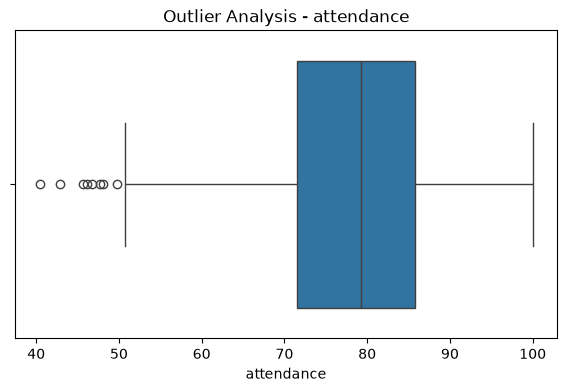

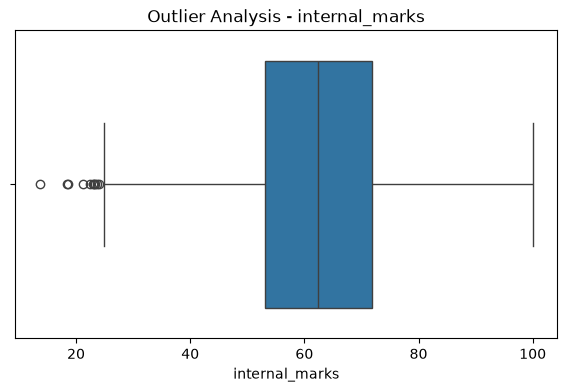

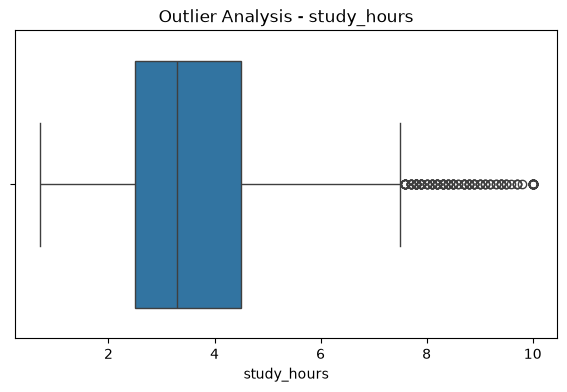

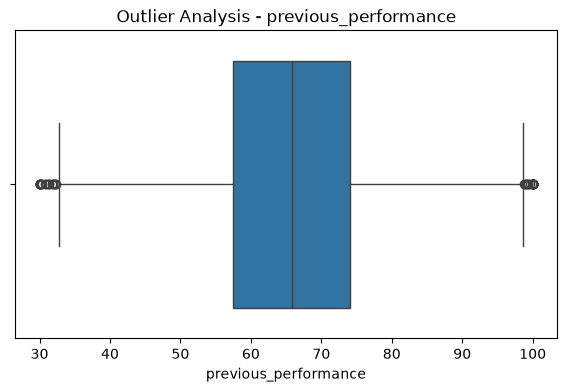

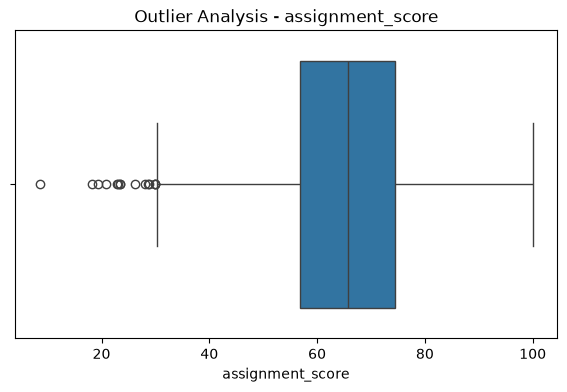

In [139]:
numeric_features = [
    "attendance",
    "internal_marks",
    "study_hours",
    "previous_performance",
    "assignment_score"
]

for column in numeric_features:

    plt.figure(figsize=(7,4))

    sns.boxplot(x=df[column])

    plt.title(f"Outlier Analysis - {column}")

    plt.show()

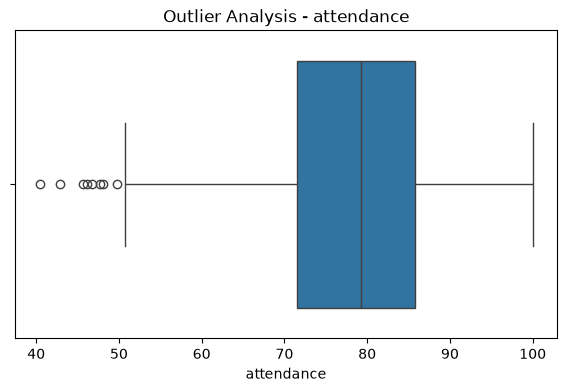

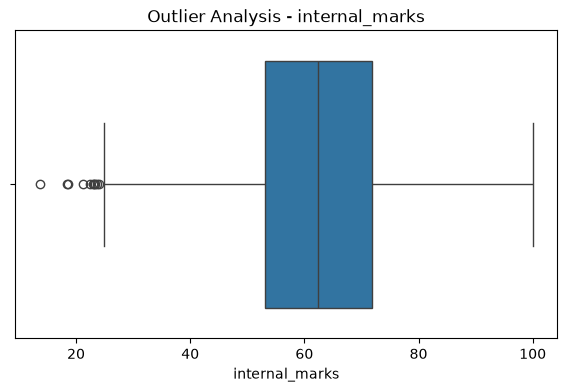

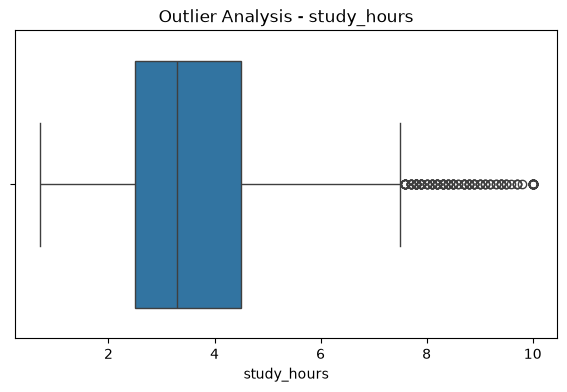

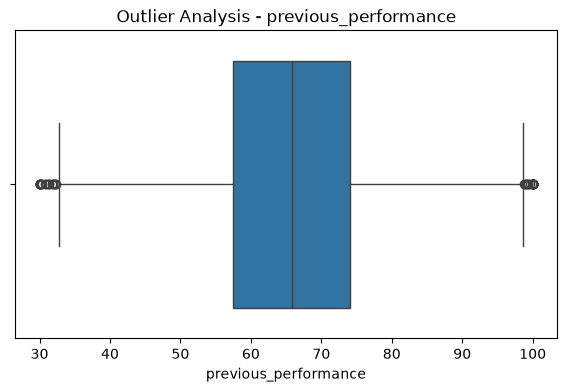

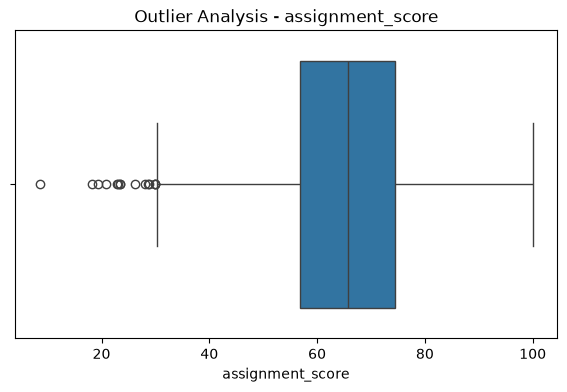

In [137]:
numeric_features = [
    "attendance",
    "internal_marks",
    "study_hours",
    "previous_performance",
    "assignment_score"
]

for column in numeric_features:

    plt.figure(figsize=(7,4))

    sns.boxplot(x=df[column])

    plt.title(f"Outlier Analysis - {column}")

    plt.show()

In [140]:
detect_outliers(df, "study_hours")

NameError: name 'detect_outliers' is not defined

In [141]:
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of outliers:", len(outliers))

    return outliers

In [142]:
detect_outliers(df, "study_hours")

Column: study_hours
Q1: 2.5
Q3: 4.5
IQR: 2.0
Lower bound: -0.5
Upper bound: 7.5
Number of outliers: 146


,student_id,attendance,internal_marks,study_hours,previous_performance,assignment_score,result
40,S00041,89.3,82.9,8.0,72.7,77.3,Pass
123,S00124,96.3,84.2,10.0,77.5,91.3,Pass
155,S00156,93.5,90.4,9.0,74.3,83.4,Pass
172,S00173,83.8,54.1,9.0,58.2,61.2,Pass
193,S00194,98.2,81.5,8.6,84.1,73.1,Pass
...,...,...,...,...,...,...,...
4918,S04919,67.2,52.2,7.6,64.1,61.1,Pass
4941,S04942,81.5,47.5,7.9,54.3,74.6,Pass
4945,S04946,85.8,68.6,9.0,82.2,59.9,Pass
4985,S04986,68.9,60.7,9.1,77.7,63.5,Pass


In [143]:
study_outliers = detect_outliers(df, "study_hours")

Column: study_hours
Q1: 2.5
Q3: 4.5
IQR: 2.0
Lower bound: -0.5
Upper bound: 7.5
Number of outliers: 146


In [144]:
print(study_outliers)

     student_id  attendance  internal_marks  study_hours  \
40       S00041        89.3            82.9          8.0   
123      S00124        96.3            84.2         10.0   
155      S00156        93.5            90.4          9.0   
172      S00173        83.8            54.1          9.0   
193      S00194        98.2            81.5          8.6   
...         ...         ...             ...          ...   
4918     S04919        67.2            52.2          7.6   
4941     S04942        81.5            47.5          7.9   
4945     S04946        85.8            68.6          9.0   
4985     S04986        68.9            60.7          9.1   
4997     S04998        87.6            57.9          7.7   

      previous_performance  assignment_score result  
40                    72.7              77.3   Pass  
123                   77.5              91.3   Pass  
155                   74.3              83.4   Pass  
172                   58.2              61.2   Pass  
193      

In [145]:
detect_outliers(df, "attendance")

Column: attendance
Q1: 71.5
Q3: 85.8
IQR: 14.299999999999997
Lower bound: 50.050000000000004
Upper bound: 107.25
Number of outliers: 8


,student_id,attendance,internal_marks,study_hours,previous_performance,assignment_score,result
1732,S01733,47.7,54.9,2.3,61.2,65.5,Fail
1811,S01812,48.1,40.2,2.4,44.2,61.9,Fail
2057,S02058,45.7,43.9,5.1,44.7,52.2,Fail
3189,S03190,49.8,59.3,4.5,55.5,64.4,Pass
3970,S03971,40.4,37.8,6.3,54.7,59.1,Fail
4106,S04107,46.1,54.6,3.3,48.7,53.8,Fail
4173,S04174,42.9,61.1,5.5,54.9,56.0,Pass
4538,S04539,46.7,72.2,3.7,76.4,69.2,Fail


In [146]:
detect_outliers(df, "internal_marks")

Column: internal_marks
Q1: 53.1
Q3: 71.9
IQR: 18.800000000000004
Lower bound: 24.899999999999995
Upper bound: 100.10000000000001
Number of outliers: 10


,student_id,attendance,internal_marks,study_hours,previous_performance,assignment_score,result
1586,S01587,62.0,22.9,1.8,52.2,39.1,Fail
2420,S02421,60.7,23.4,2.3,51.1,68.3,Fail
3266,S03267,72.2,22.5,1.8,52.9,29.9,Fail
3277,S03278,60.8,13.6,3.3,44.3,60.6,Fail
3361,S03362,56.3,24.0,3.8,43.1,40.2,Fail
3755,S03756,62.0,18.4,2.2,57.4,80.0,Fail
3887,S03888,87.0,23.7,2.3,57.5,50.2,Fail
4069,S04070,66.7,18.6,3.9,38.2,66.0,Fail
4616,S04617,58.9,21.3,0.8,46.1,30.5,Fail
4636,S04637,91.1,23.2,2.9,30.9,55.0,Fail


In [147]:
detect_outliers(df, "study_hours")

Column: study_hours
Q1: 2.5
Q3: 4.5
IQR: 2.0
Lower bound: -0.5
Upper bound: 7.5
Number of outliers: 146


,student_id,attendance,internal_marks,study_hours,previous_performance,assignment_score,result
40,S00041,89.3,82.9,8.0,72.7,77.3,Pass
123,S00124,96.3,84.2,10.0,77.5,91.3,Pass
155,S00156,93.5,90.4,9.0,74.3,83.4,Pass
172,S00173,83.8,54.1,9.0,58.2,61.2,Pass
193,S00194,98.2,81.5,8.6,84.1,73.1,Pass
...,...,...,...,...,...,...,...
4918,S04919,67.2,52.2,7.6,64.1,61.1,Pass
4941,S04942,81.5,47.5,7.9,54.3,74.6,Pass
4945,S04946,85.8,68.6,9.0,82.2,59.9,Pass
4985,S04986,68.9,60.7,9.1,77.7,63.5,Pass


In [148]:
detect_outliers(df, "previous_performance")

Column: previous_performance
Q1: 57.475
Q3: 74.0
IQR: 16.525
Lower bound: 32.6875
Upper bound: 98.7875
Number of outliers: 44


,student_id,attendance,internal_marks,study_hours,previous_performance,assignment_score,result
141,S00142,73.8,62.1,2.7,32.2,67.9,Pass
162,S00163,98.6,82.7,4.5,99.2,72.9,Pass
183,S00184,87.0,76.9,3.4,100.0,91.8,Pass
452,S00453,85.4,84.3,4.8,98.8,72.3,Pass
631,S00632,75.2,72.3,6.1,100.0,83.5,Pass
846,S00847,79.9,78.0,4.4,100.0,76.5,Pass
947,S00948,64.9,34.5,2.1,31.9,23.0,Fail
950,S00951,71.0,55.3,4.3,30.8,60.4,Fail
1053,S01054,88.2,97.8,2.1,100.0,70.0,Pass
1315,S01316,89.6,79.1,2.8,99.4,76.7,Pass


In [149]:
detect_outliers(df, "assignment_score")

Column: assignment_score
Q1: 56.8
Q3: 74.5
IQR: 17.700000000000003
Lower bound: 30.249999999999993
Upper bound: 101.05000000000001
Number of outliers: 15


,student_id,attendance,internal_marks,study_hours,previous_performance,assignment_score,result
236,S00237,85.9,44.6,1.2,39.0,30.0,Fail
534,S00535,69.6,49.5,1.8,55.0,22.8,Fail
947,S00948,64.9,34.5,2.1,31.9,23.0,Fail
986,S00987,64.0,68.9,2.0,52.0,20.8,Fail
1674,S01675,72.4,59.4,2.6,81.2,18.2,Fail
1711,S01712,75.8,26.4,4.7,42.0,26.3,Fail
1790,S01791,57.8,41.2,2.0,57.5,29.9,Fail
1913,S01914,66.4,31.7,1.5,58.3,8.5,Fail
2568,S02569,66.4,48.4,3.4,60.7,19.4,Fail
3003,S03004,65.0,42.5,2.7,48.2,28.0,Fail


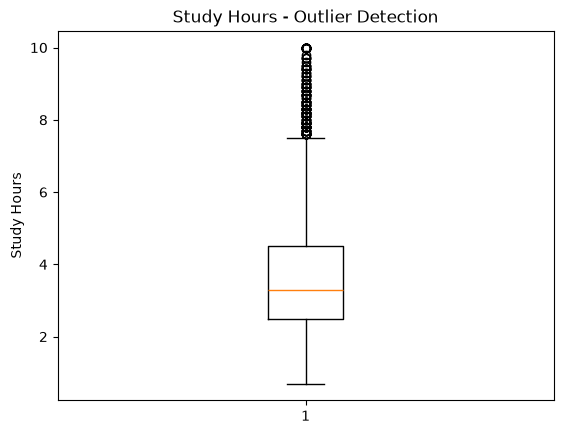

In [150]:
import matplotlib.pyplot as plt

plt.boxplot(df["study_hours"].dropna())
plt.title("Study Hours - Outlier Detection")
plt.ylabel("Study Hours")
plt.show()

In [151]:
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of outliers:", len(outliers))

    return outliers

In [152]:
detect_outliers(df, "study_hours")

Column: study_hours
Q1: 2.5
Q3: 4.5
IQR: 2.0
Lower bound: -0.5
Upper bound: 7.5
Number of outliers: 146


,student_id,attendance,internal_marks,study_hours,previous_performance,assignment_score,result
40,S00041,89.3,82.9,8.0,72.7,77.3,Pass
123,S00124,96.3,84.2,10.0,77.5,91.3,Pass
155,S00156,93.5,90.4,9.0,74.3,83.4,Pass
172,S00173,83.8,54.1,9.0,58.2,61.2,Pass
193,S00194,98.2,81.5,8.6,84.1,73.1,Pass
...,...,...,...,...,...,...,...
4918,S04919,67.2,52.2,7.6,64.1,61.1,Pass
4941,S04942,81.5,47.5,7.9,54.3,74.6,Pass
4945,S04946,85.8,68.6,9.0,82.2,59.9,Pass
4985,S04986,68.9,60.7,9.1,77.7,63.5,Pass


In [155]:
df["academic_average"] = (
    df["internal_marks"] +
    df["previous_performance"] +
    df["assignment_score"]
) / 3

In [156]:
df["study_efficiency"] = (
    df["academic_average"] /
    (df["study_hours"] + 1)
)

In [157]:
df["attendance_category"] = pd.cut(
    df["attendance"],
    bins=[0, 60, 75, 85, 100],
    labels=[
        "Low",
        "Average",
        "Good",
        "Excellent"
    ]
)

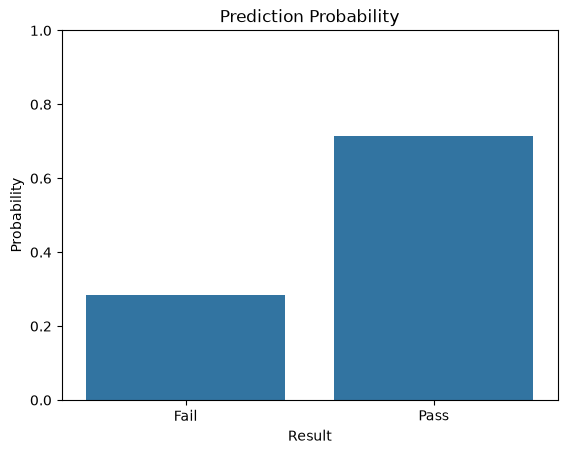

In [158]:
probabilities = model.predict_proba(student)[0]

prob_df = pd.DataFrame({
    "Result": model.classes_,
    "Probability": probabilities
})

sns.barplot(
    data=prob_df,
    x="Result",
    y="Probability"
)

plt.ylim(0, 1)
plt.title("Prediction Probability")
plt.show()

In [159]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

In [160]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [161]:
lr_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("LR CV Scores:", lr_scores)
print("Mean Accuracy:", lr_scores.mean())

LR CV Scores: [0.793 0.767 0.807 0.783 0.785]
Mean Accuracy: 0.787


In [162]:
dt_scores = cross_val_score(
    decision_tree_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("DT CV Scores:", dt_scores)
print("Mean Accuracy:", dt_scores.mean())

DT CV Scores: [0.767 0.741 0.764 0.762 0.768]
Mean Accuracy: 0.7604000000000001


In [163]:
print("Mean:", lr_scores.mean())
print("Standard Deviation:", lr_scores.std())

Mean: 0.787
Standard Deviation: 0.013084341787036912


In [164]:
DecisionTreeClassifier()

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl

In [165]:
from sklearn.model_selection import GridSearchCV

In [166]:
param_grid = {
    "classifier__max_depth": [3, 4, 5, 6, 8, 10],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

In [167]:
grid_search = GridSearchCV(
    decision_tree_model,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [3, 4, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",T

In [168]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2}
0.75925


In [170]:
param_grid_lr = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

In [172]:
grid_lr = GridSearchCV(
    logistic_model,
    param_grid_lr,
    cv=5,
    scoring="accuracy"
)

grid_lr.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fi

In [173]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, pos_label="Pass"),
        precision_score(y_test, y_pred_dt, pos_label="Pass")
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, pos_label="Pass"),
        recall_score(y_test, y_pred_dt, pos_label="Pass")
    ],
    "F1": [
        f1_score(y_test, y_pred_lr, pos_label="Pass"),
        f1_score(y_test, y_pred_dt, pos_label="Pass")
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.796,0.825000,0.898281,0.860082
1,Decision Tree,0.759,0.790343,0.891117,0.837710


In [174]:
from sklearn.metrics import roc_auc_score

In [175]:
lr_probability = logistic_model.predict_proba(X_test)[:, 1]

In [176]:
roc_auc_score(y_test, lr_probability)

0.8348640391658286

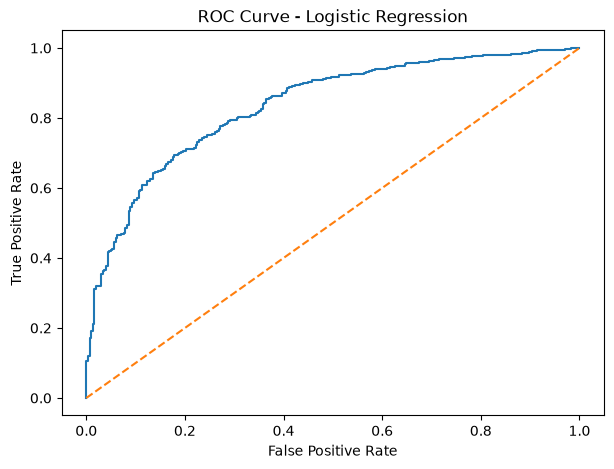

In [177]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    lr_probability,
    pos_label="Pass"
)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.show()

In [178]:
from sklearn.metrics import precision_recall_curve

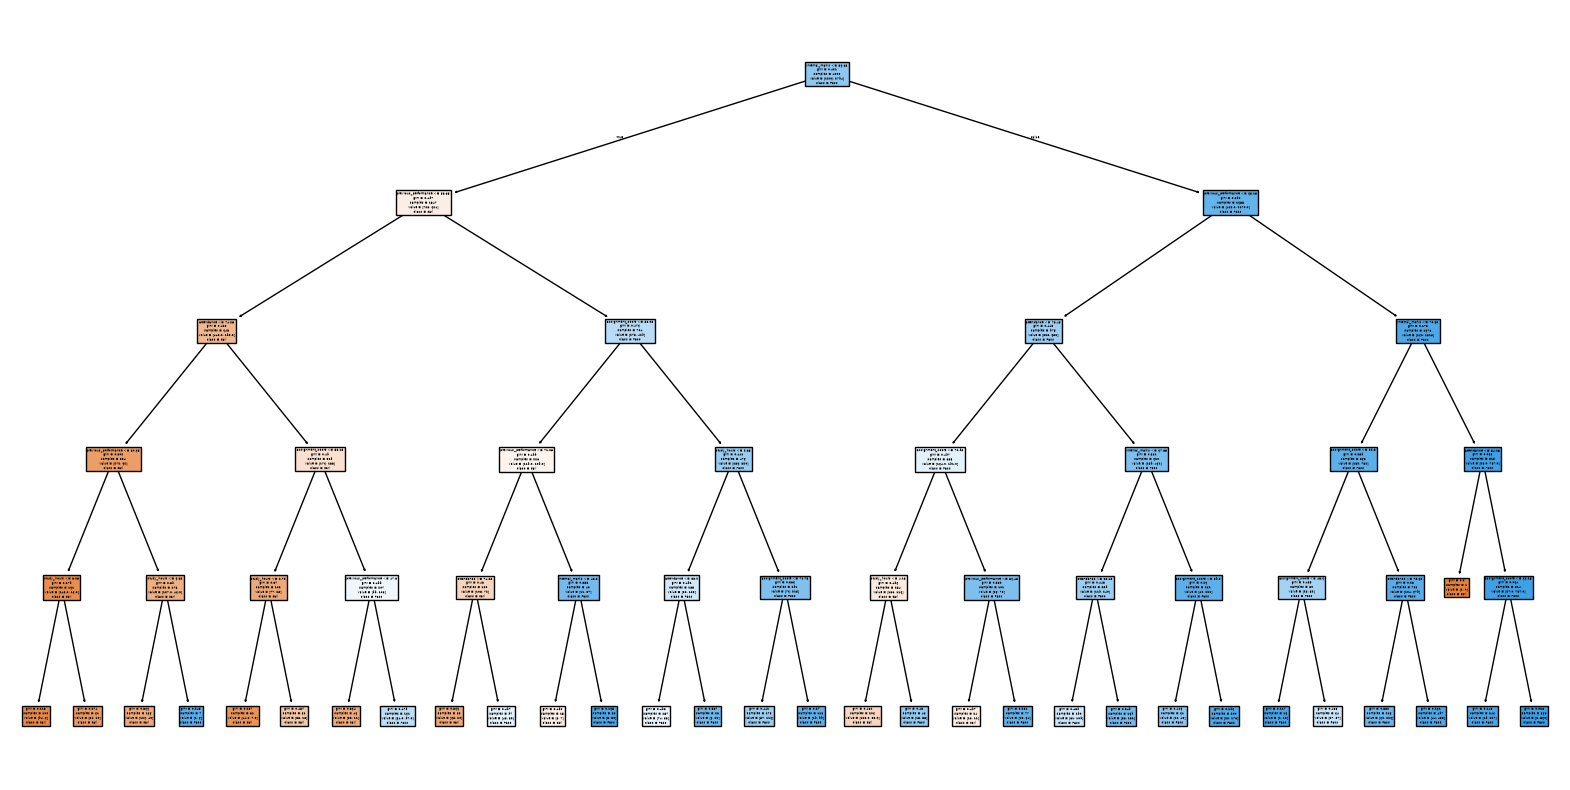

In [180]:
from sklearn.tree import plot_tree

tree_model = decision_tree_model.named_steps["classifier"]

plt.figure(figsize=(20,10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=tree_model.classes_,
    filled=True
)

plt.show()

In [181]:
lr_classifier = logistic_model.named_steps["classifier"]

In [182]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_classifier.coef_[0]
})

coefficients

,Feature,Coefficient
0,attendance,0.429160
1,internal_marks,0.703182
2,study_hours,0.286021
3,previous_performance,0.661452
4,assignment_score,0.384075


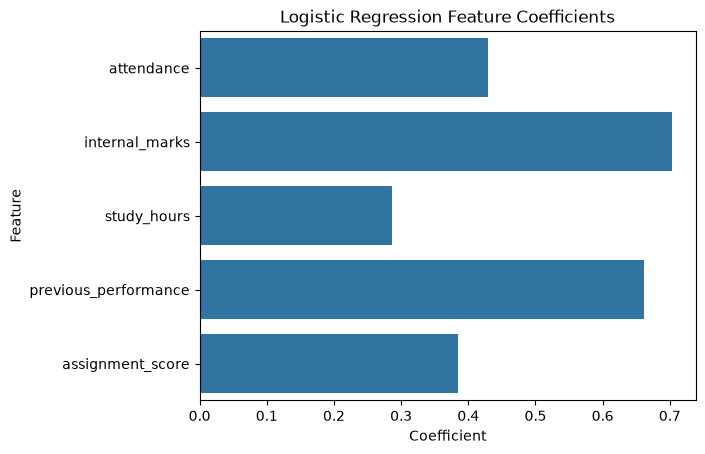

In [183]:
sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Feature Coefficients")
plt.show()

In [184]:
import joblib

model = joblib.load("../models/best_model.pkl")

print(model)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', LogisticRegression(max_iter=2000))])


In [185]:
print(type(model.named_steps["model"]))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [186]:
coefficients = model.named_steps["model"].coef_[0]

print(coefficients)

[0.42916048 0.70318195 0.28602143 0.66145219 0.38407545]


In [187]:
feature_names = [
    "attendance",
    "internal_marks",
    "study_hours",
    "previous_performance",
    "assignment_score"
]

In [189]:
import numpy as np

importance = np.abs(coefficients)

print(importance)

[0.42916048 0.70318195 0.28602143 0.66145219 0.38407545]


In [190]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance

,Feature,Importance
0,attendance,0.429160
1,internal_marks,0.703182
2,study_hours,0.286021
3,previous_performance,0.661452
4,assignment_score,0.384075


In [191]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,internal_marks,0.703182
3,previous_performance,0.661452
0,attendance,0.429160
4,assignment_score,0.384075
2,study_hours,0.286021


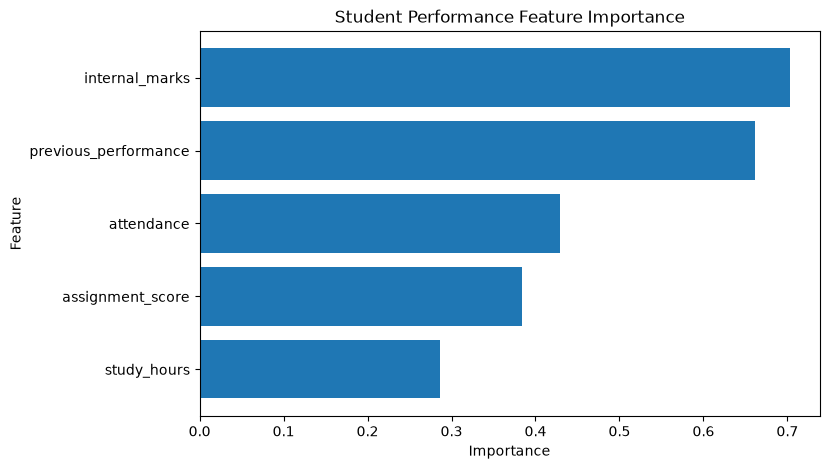

In [192]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Student Performance Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [193]:
lr_classifier = logistic_model.named_steps["classifier"]

In [194]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_classifier.coef_[0]
})

coefficients

,Feature,Coefficient
0,attendance,0.429160
1,internal_marks,0.703182
2,study_hours,0.286021
3,previous_performance,0.661452
4,assignment_score,0.384075


In [195]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_classifier.coef_[0]
})

coefficients

,Feature,Coefficient
0,attendance,0.429160
1,internal_marks,0.703182
2,study_hours,0.286021
3,previous_performance,0.661452
4,assignment_score,0.384075
